<a href="https://colab.research.google.com/github/shashin2000/Adithaalama-multitools/blob/main/AI_ML%202026.5.11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
np.random.seed(42)
print("Libraries loaded")

Libraries loaded


In [16]:
df = pd.read_csv("/content/house_rent_dataset.csv")
df.head() # produce 1st five rows


,size_sqft,bedrooms,building_age,distance_km,rent,high_rent
0,1360,5,17,2,2466.641515,0
1,1794,5,14,12,2693.402019,1
2,1630,1,8,3,2283.011027,0
3,1595,3,16,3,2425.864353,0
4,2138,2,13,1,3170.570731,1


In [17]:
# rows and column
df.shape # 300 rows and 6 columns

(300, 6)

In [18]:
df.columns


Index(['size_sqft', 'bedrooms', 'building_age', 'distance_km', 'rent',
       'high_rent'],
      dtype='object')

In [19]:
# Data tytpes of each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   size_sqft     300 non-null    int64  
 1   bedrooms      300 non-null    int64  
 2   building_age  300 non-null    int64  
 3   distance_km   300 non-null    int64  
 4   rent          300 non-null    float64
 5   high_rent     300 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 14.2 KB


In [20]:
# missing isnull()
print(df.isnull().sum())

size_sqft       0
bedrooms        0
building_age    0
distance_km     0
rent            0
high_rent       0
dtype: int64


In [21]:
# understanding the dataset
df.describe() # mean, Q1, Q3, SD, etc

,size_sqft,bedrooms,building_age,distance_km,rent,high_rent
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1790.583333,3.080000,9.296667,12.273333,2551.204403,0.500000
std,687.159533,1.458546,5.856876,7.261385,1111.272251,0.500835
min,501.000000,1.000000,0.000000,1.000000,500.000000,0.000000
25%,1198.750000,2.000000,4.000000,6.000000,1749.149137,0.000000
50%,1803.000000,3.000000,9.500000,12.000000,2510.808947,0.500000
75%,2355.500000,4.000000,14.000000,19.000000,3250.217332,1.000000
max,2989.000000,5.000000,19.000000,24.000000,5199.688754,1.000000


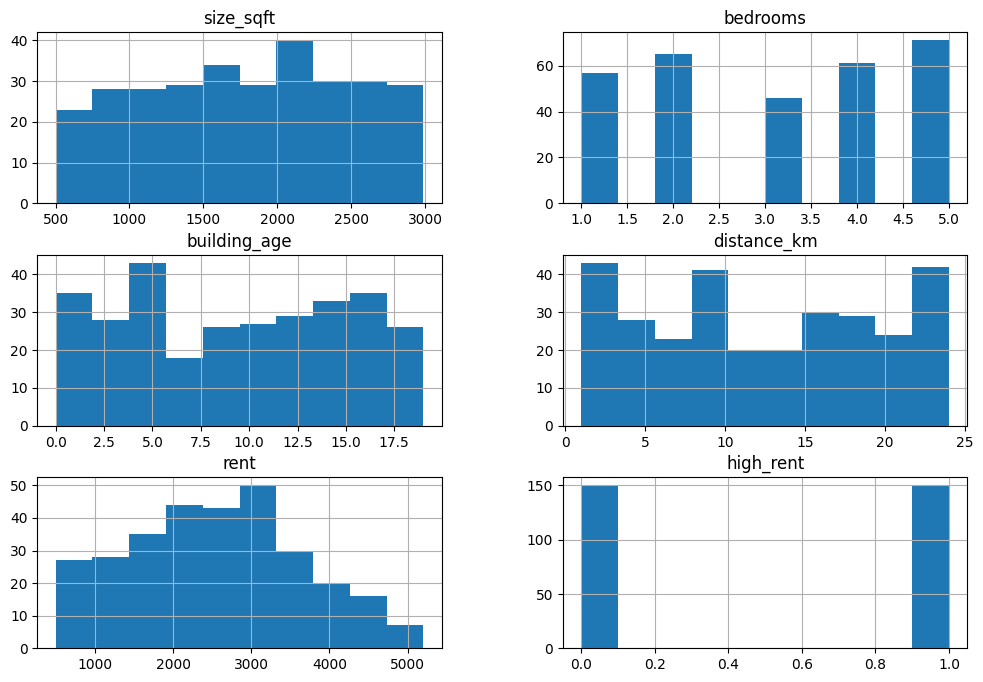

In [22]:
# Visualization
df.hist(figsize=(12,8))
plt.show()

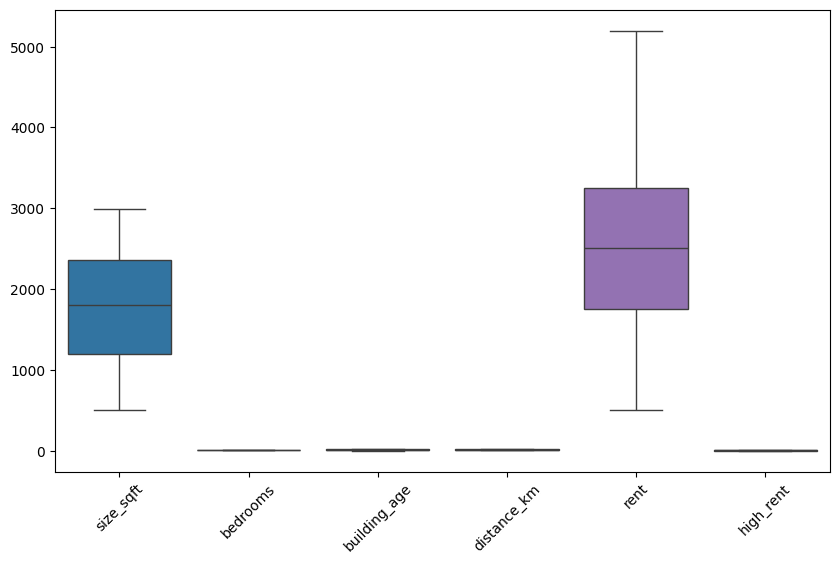

In [23]:
#outliers checking - Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

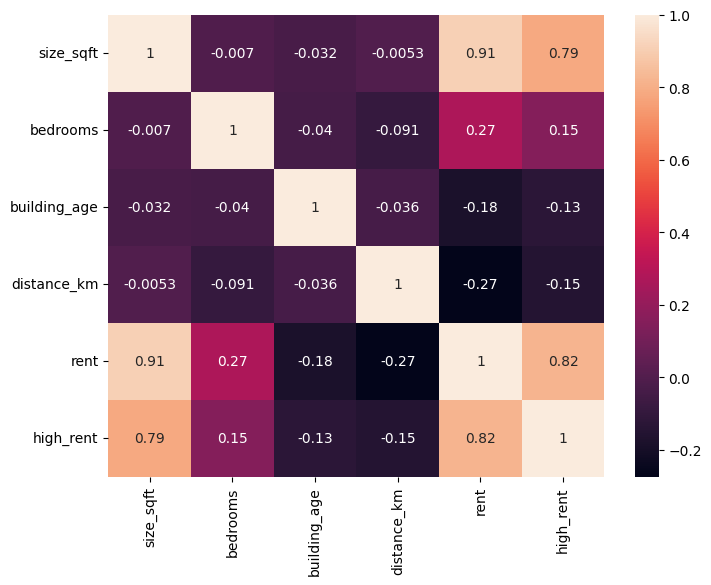

In [24]:
# correlation
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [25]:
# Divide data into two units are called X, and y '
X = df[['size_sqft', 'bedrooms', 'building_age', 'distance_km']]
y = df['rent'] # target class

In [29]:
X.head()


,size_sqft,bedrooms,building_age,distance_km
0,1360,5,17,2
1,1794,5,14,12
2,1630,1,8,3
3,1595,3,16,3
4,2138,2,13,1


In [27]:
y.head()

,rent
0,2466.641515
1,2693.402019
2,2283.011027
3,2425.864353
4,3170.570731


In [30]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((240, 4), (60, 4), (240,), (60,))

TRAIN MODEL

In [33]:
#Regrassion model
from sklearn.linear_model import LinearRegression
model = LinearRegression()#in built
model.fit(x_train,y_train)

LinearRegression()

In [35]:
y_pred = model.predict(x_test)

y_pred = model.predict(x_test)
    =model _predict (S5 98 6)
    =must be 92
    =what if we get 89?
MAE = must be small
MAE = 92-89 =3

MAE = mean absolute value



In [38]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

#always MAE and RMSE must be small value ( min rent = 500 , max rent = 5199)
# R2 always higers value ( 0 -1 )

MAE: 91.31
RMSE: 114.41
R2 Score: 0.99


In [39]:
# performance of the model

new_house = pd.DataFrame({
    'size_sqft': [1500],
    'bedrooms': [3],
    'building_age': [5],
    'distance_km': [8]
})

# already trained model
predicted_rent = model.predict(new_house)
print(f"Predicted Rent: ${predicted_rent[0]:.2f}")

Predicted Rent: $2399.16


In [42]:
# traininng with only one model is not sufficient
# Regression - LinearRegression, RandomForestRegression

# n_estimator = number of trees


#Regrassion model
from sklearn.ensemble import RandomForestRegressor
#model = LinearRegression()#in built
#model.fit(x_train,y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)


RandomForestRegressor(random_state=42)

In [43]:
#y_pred = model.predict(x_test)

y_pred = rf_model.predict(x_test)

In [45]:

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results :")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Random Forest Results :
MAE: 187.72
RMSE: 224.88
R2 Score: 0.96


**Student Performance**

In [48]:
df = pd.read_csv("/content/student_performance_sample_dataset.csv")
df.head() # produce 1 st five rows

,hours_study,attendance_percent,previous_score,practice_tests,sleep_hours,final_score,pass_fail
0,6.2,66.3,59.6,3,7.4,70.0,0
1,4.9,87.4,67.5,2,7.8,83.2,1
2,6.6,91.9,44.9,3,7.8,76.4,1
3,8.4,68.2,91.5,5,6.4,96.0,1
4,4.7,89.6,41.9,4,6.9,71.0,0


In [49]:
df.shape #column and row count


(160, 7)

In [50]:
df.columns # columns names

Index(['hours_study', 'attendance_percent', 'previous_score', 'practice_tests',
       'sleep_hours', 'final_score', 'pass_fail'],
      dtype='object')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hours_study         160 non-null    float64
 1   attendance_percent  160 non-null    float64
 2   previous_score      160 non-null    float64
 3   practice_tests      160 non-null    int64  
 4   sleep_hours         160 non-null    float64
 5   final_score         160 non-null    float64
 6   pass_fail           160 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 8.9 KB


In [52]:
df.describe()

,hours_study,attendance_percent,previous_score,practice_tests,sleep_hours,final_score,pass_fail
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,5.055625,78.776250,58.340000,3.806250,6.549375,76.911875,0.537500
std,1.947446,11.128243,15.881698,1.858169,1.067001,12.241744,0.500157
min,0.500000,39.100000,21.200000,0.000000,4.000000,45.300000,0.000000
25%,3.800000,70.425000,46.375000,2.000000,5.700000,68.975000,0.000000
50%,5.100000,79.400000,57.950000,4.000000,6.600000,76.900000,1.000000
75%,6.200000,86.700000,68.400000,5.000000,7.200000,85.925000,1.000000
max,10.000000,100.000000,95.000000,10.000000,9.000000,100.000000,1.000000


In [53]:
# empty values

print(df.isnull().sum())

hours_study           0
attendance_percent    0
previous_score        0
practice_tests        0
sleep_hours           0
final_score           0
pass_fail             0
dtype: int64


In [56]:
# Duplicate values

print(df.duplicated().sum())

0


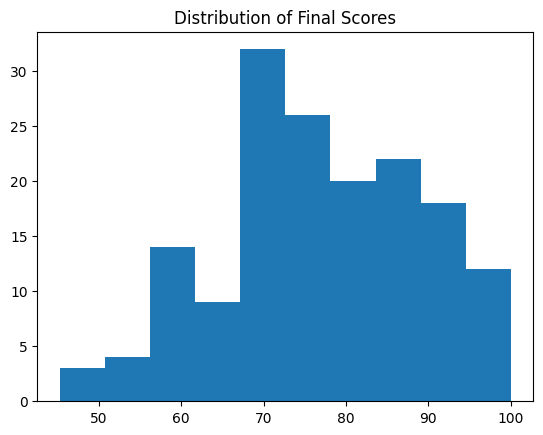

In [57]:
plt.hist(df['final_score'])
plt.title('Distribution of Final Scores')
plt.show()

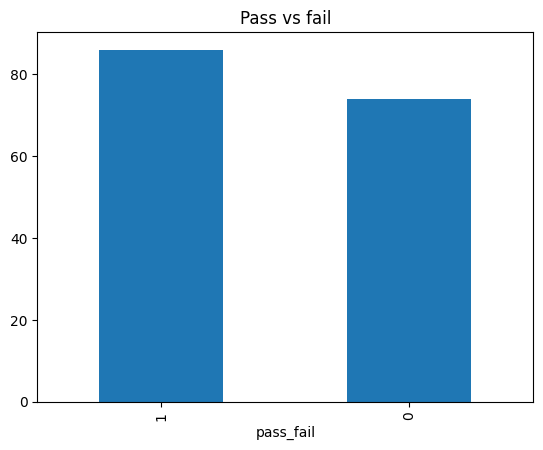

In [59]:
df['pass_fail'].value_counts().plot(kind='bar')
plt.title('Pass vs fail')
plt.show()

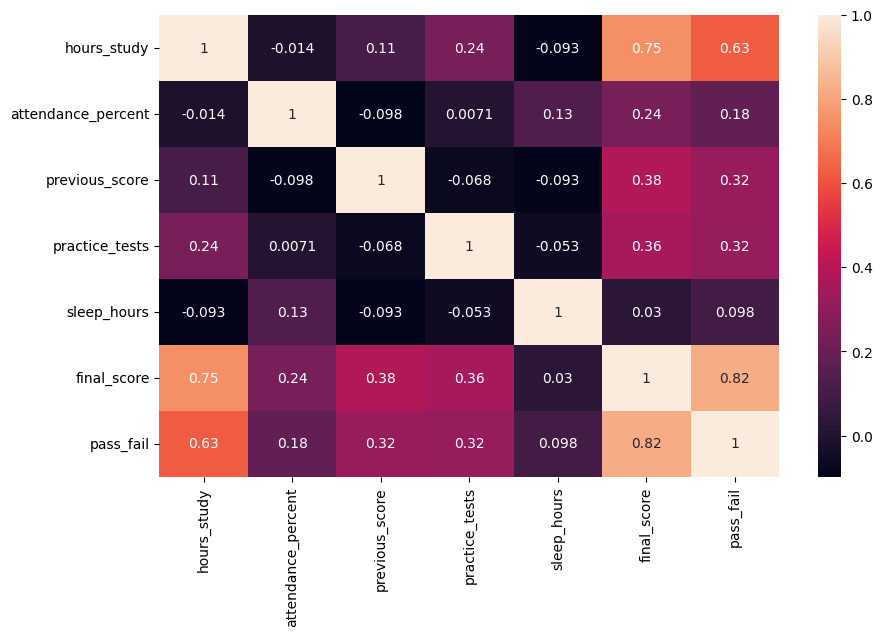

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Features
X = df[['hours_study', 'attendance_percent', 'previous_score',
        'practice_tests', 'sleep_hours']]
# Target for regression
y = df['final_score']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)
# Prediction
y_pred = reg_model.predict(X_test_scaled)
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print("Random Forest Results :")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Random Forest Results :
MAE: 4.27
RMSE: 5.89
R2 Score: 0.69


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Features
X = df[['hours_study', 'attendance_percent', 'previous_score',
        'practice_tests', 'sleep_hours']]
# Target for classification
y = df['pass_fail']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train model
clf_model = LogisticRegression()
clf_model.fit(X_train_scaled, y_train)
# Prediction
y_pred = clf_model.predict(X_test_scaled)
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("CLASSIFICATION RESULTS")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

CLASSIFICATION RESULTS
Accuracy: 0.875
Precision: 0.9333333333333333
Recall: 0.8235294117647058
F1 Score: 0.875
Confusion Matrix:
[[14  1]
 [ 3 14]]
